In [ ]:
# import libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import LabelEncoder

In [8]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [ ]:
#load dataset
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")
sample = pd.read_csv("dataset/sample_submission.csv")

In [15]:
train

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,qp0d4n,49,2:0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,77295,qp0d4q,49,2:0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,77296,qp0d4w,49,2:0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,77297,qp0dhw,49,2:0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


In [16]:
test

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy
...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy


In [17]:
sample

,Index,demand
0,0,0.090768
1,1,0.089885
2,2,0.007037
3,3,0.079087
4,4,0.054636


In [13]:
train.shape

(77299, 11)

In [14]:
test.shape

(41778, 10)

In [ ]:
# View Data

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [ ]:
# Dataset Info

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 9.3 MB


In [ ]:
# Missing Values

train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

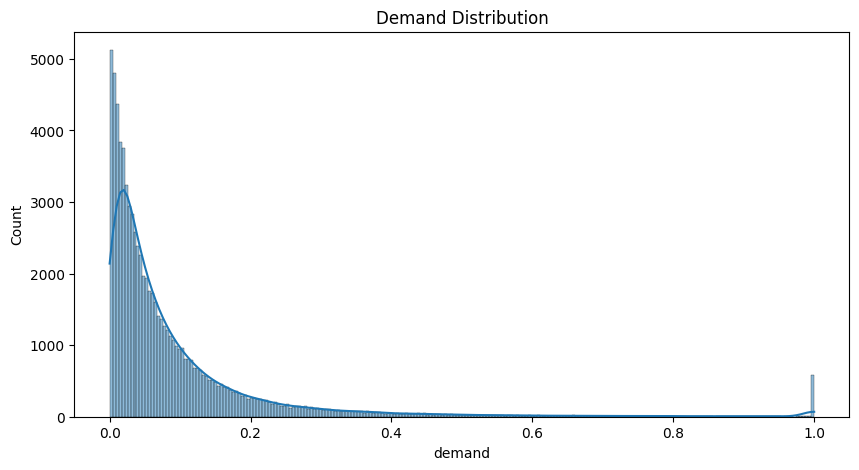

In [ ]:
# Target Distribution

plt.figure(figsize=(10,5))

sns.histplot(train["demand"], kde=True)

plt.title("Demand Distribution")

plt.show()

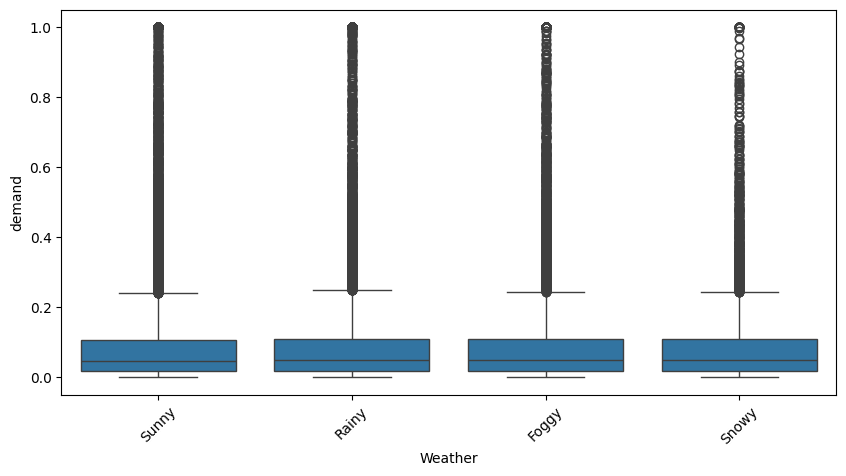

In [ ]:
# Weather vs Demand

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train["Weather"],
    y=train["demand"]
)

plt.xticks(rotation=45)

plt.show()

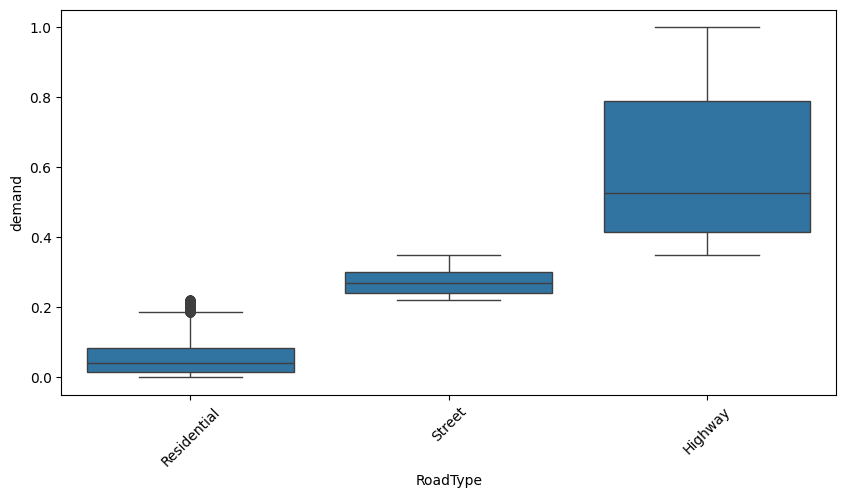

In [ ]:
# RoadType vs Demand

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train["RoadType"],
    y=train["demand"]
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Fill Missing Values
categorical_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

for col in categorical_cols:

    train[col] = train[col].fillna("Unknown")

    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(
    train["Temperature"].median()
)

test["Temperature"] = test["Temperature"].fillna(
    test["Temperature"].median()
)

In [ ]:
# Check Missing Values

train.isnull().sum()

Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

In [ ]:
# Feature Engineering Function

def create_features(df):

    df["hour"] = df["timestamp"].apply(
        lambda x: int(x.split(":")[0])
    )

    df["minute"] = df["timestamp"].apply(
        lambda x: int(x.split(":")[1])
    )

    df["is_weekend"] = df["day"].apply(
        lambda x: 1 if x % 7 in [5,6] else 0
    )

    df["rush_hour"] = df["hour"].apply(
        lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0
    )

    df["night"] = df["hour"].apply(
        lambda x: 1 if (x >= 22 or x <= 5) else 0
    )

    def bucket(h):

        if 5 <= h < 10:
            return "Morning"

        elif 10 <= h < 16:
            return "Afternoon"

        elif 16 <= h < 21:
            return "Evening"

        else:
            return "Night"

    df["time_bucket"] = df["hour"].apply(bucket)

    df["lane_temp"] = (
        df["NumberofLanes"] *
        df["Temperature"]
    )

    df["temp_hour"] = (
        df["Temperature"] *
        df["hour"]
    )

    return df

In [ ]:
# Create Features

train = create_features(train)

test = create_features(test)

In [ ]:
# View Features

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour
0,0,qp02z1,48,0:0,0.048804,Unknown,1,Not Allowed,No,16.382587,Unknown,0,0,1,0,1,Night,16.382587,0.0
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,1,0,1,Night,93.313694,0.0
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,1,0,1,Night,25.919267,0.0
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,16.382587,Rainy,0,0,1,0,1,Night,16.382587,0.0
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,1,0,1,Night,10.803667,0.0


In [35]:
test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,0,qp02z1,49,2:15,Unknown,1,Not Allowed,No,16.471232,Unknown,2,15,0,0,1,Night,16.471232,32.942464,0.040048
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy,2,15,0,0,1,Night,6.476213,12.952427,0.031742
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny,2,15,0,0,1,Night,66.954608,44.636405,0.029433
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,16.471232,Rainy,2,15,0,0,1,Night,32.942464,32.942464,0.039944
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy,2,15,0,0,1,Night,18.266162,36.532324,0.054593


In [ ]:
# Geohash Encoding
geo_mean = train.groupby("geohash")["demand"].mean()

train["geo_demand_mean"] = train["geohash"].map(geo_mean)

test["geo_demand_mean"] = test["geohash"].map(geo_mean)

test["geo_demand_mean"] = test["geo_demand_mean"].fillna(
    train["demand"].mean()
)

In [33]:
geo_mean

geohash
qp02yc    0.018498
qp02yf    0.029433
qp02yy    0.002902
qp02yz    0.036564
qp02z1    0.040048
            ...   
qp0dn4    0.007811
qp0dn5    0.003714
qp0dnh    0.001401
qp0dnj    0.026414
qp0dnn    0.004244
Name: demand, Length: 1249, dtype: float64

In [ ]:
# Merge Data

all_data = pd.concat([
    train.drop(columns=["demand"]),
    test
])

In [32]:
all_data

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,0,qp02z1,48,0:0,Unknown,1,Not Allowed,No,16.382587,Unknown,0,0,1,0,1,Night,16.382587,0.000000,0.040048
1,1,qp02zt,48,0:0,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,1,0,1,Night,93.313694,0.000000,0.208766
2,2,qp08bj,48,0:0,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,1,0,1,Night,25.919267,0.000000,0.127931
3,3,qp08gt,48,0:0,Residential,1,Not Allowed,No,16.382587,Rainy,0,0,1,0,1,Night,16.382587,0.000000,0.014381
4,4,qp02zq,48,0:0,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,1,0,1,Night,10.803667,0.000000,0.029300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny,13,45,0,0,0,Afternoon,19.588991,254.656882,0.139208
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy,13,45,0,0,0,Afternoon,21.471075,139.561989,0.113220
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy,13,45,0,0,0,Afternoon,26.447500,171.908747,0.018066
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy,13,45,0,0,0,Afternoon,25.021834,162.641918,0.075075


In [ ]:
# Label Encoding

label_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "time_bucket"
]

for col in label_cols:

    le = LabelEncoder()

    all_data[col] = le.fit_transform(
        all_data[col].astype(str)
    )

In [69]:
all_data

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,0,4,48,0:0,3,1,1,0,16.382587,4,0,0,1,0,1,3,16.382587,0.000000,0.040048
1,1,25,48,0:0,1,3,0,1,31.104565,3,0,0,1,0,1,3,93.313694,0.000000,0.208766
2,2,370,48,0:0,1,1,1,0,25.919267,3,0,0,1,0,1,3,25.919267,0.000000,0.127931
3,3,418,48,0:0,1,1,1,0,16.382587,1,0,0,1,0,1,3,16.382587,0.000000,0.014381
4,4,22,48,0:0,1,1,1,0,10.803667,1,0,0,1,0,1,3,10.803667,0.000000,0.029300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,1170,49,13:45,2,1,1,1,19.588991,3,13,45,0,0,0,0,19.588991,254.656882,0.139208
41774,41774,1175,49,13:45,1,2,1,1,10.735538,1,13,45,0,0,0,0,21.471075,139.561989,0.113220
41775,41775,1218,49,13:45,1,2,1,1,13.223750,1,13,45,0,0,0,0,26.447500,171.908747,0.018066
41776,41776,1223,49,13:45,1,2,1,1,12.510917,1,13,45,0,0,0,0,25.021834,162.641918,0.075075


In [ ]:
# Split Data

train_encoded = all_data.iloc[:len(train)]

test_encoded = all_data.iloc[len(train):]

In [70]:
train_encoded

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,0,4,48,0:0,3,1,1,0,16.382587,4,0,0,1,0,1,3,16.382587,0.000000,0.040048
1,1,25,48,0:0,1,3,0,1,31.104565,3,0,0,1,0,1,3,93.313694,0.000000,0.208766
2,2,370,48,0:0,1,1,1,0,25.919267,3,0,0,1,0,1,3,25.919267,0.000000,0.127931
3,3,418,48,0:0,1,1,1,0,16.382587,1,0,0,1,0,1,3,16.382587,0.000000,0.014381
4,4,22,48,0:0,1,1,1,0,10.803667,1,0,0,1,0,1,3,10.803667,0.000000,0.029300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,77294,1169,49,2:0,1,1,1,0,11.501664,1,2,0,0,0,1,3,11.501664,23.003328,0.026510
77295,77295,1170,49,2:0,1,3,0,1,14.715254,0,2,0,0,0,1,3,44.145761,29.430507,0.139208
77296,77296,1175,49,2:0,1,3,0,1,19.678860,3,2,0,0,0,1,3,59.036579,39.357720,0.113220
77297,77297,1223,49,2:0,1,1,1,0,22.573958,3,2,0,0,0,1,3,22.573958,45.147916,0.075075


In [71]:
test_encoded

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,0,4,49,2:15,3,1,1,0,16.471232,4,2,15,0,0,1,3,16.471232,32.942464,0.040048
1,1,10,49,2:15,1,1,1,0,6.476213,2,2,15,0,0,1,3,6.476213,12.952427,0.031742
2,2,1,49,2:15,1,3,0,1,22.318203,3,2,15,0,0,1,3,66.954608,44.636405,0.029433
3,3,8,49,2:15,1,2,1,1,16.471232,1,2,15,0,0,1,3,32.942464,32.942464,0.039944
4,4,12,49,2:15,1,1,1,0,18.266162,0,2,15,0,0,1,3,18.266162,36.532324,0.054593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,1170,49,13:45,2,1,1,1,19.588991,3,13,45,0,0,0,0,19.588991,254.656882,0.139208
41774,41774,1175,49,13:45,1,2,1,1,10.735538,1,13,45,0,0,0,0,21.471075,139.561989,0.113220
41775,41775,1218,49,13:45,1,2,1,1,13.223750,1,13,45,0,0,0,0,26.447500,171.908747,0.018066
41776,41776,1223,49,13:45,1,2,1,1,12.510917,1,13,45,0,0,0,0,25.021834,162.641918,0.075075


In [ ]:
# Create X and y

X = train_encoded.drop(columns=[
    "Index",
    "timestamp"
])

y = train["demand"]

X_test = test_encoded.drop(columns=[
    "Index",
    "timestamp"
])

In [73]:
X

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,4,48,3,1,1,0,16.382587,4,0,0,1,0,1,3,16.382587,0.000000,0.040048
1,25,48,1,3,0,1,31.104565,3,0,0,1,0,1,3,93.313694,0.000000,0.208766
2,370,48,1,1,1,0,25.919267,3,0,0,1,0,1,3,25.919267,0.000000,0.127931
3,418,48,1,1,1,0,16.382587,1,0,0,1,0,1,3,16.382587,0.000000,0.014381
4,22,48,1,1,1,0,10.803667,1,0,0,1,0,1,3,10.803667,0.000000,0.029300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,1169,49,1,1,1,0,11.501664,1,2,0,0,0,1,3,11.501664,23.003328,0.026510
77295,1170,49,1,3,0,1,14.715254,0,2,0,0,0,1,3,44.145761,29.430507,0.139208
77296,1175,49,1,3,0,1,19.678860,3,2,0,0,0,1,3,59.036579,39.357720,0.113220
77297,1223,49,1,1,1,0,22.573958,3,2,0,0,0,1,3,22.573958,45.147916,0.075075


In [74]:
X_test

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,4,49,3,1,1,0,16.471232,4,2,15,0,0,1,3,16.471232,32.942464,0.040048
1,10,49,1,1,1,0,6.476213,2,2,15,0,0,1,3,6.476213,12.952427,0.031742
2,1,49,1,3,0,1,22.318203,3,2,15,0,0,1,3,66.954608,44.636405,0.029433
3,8,49,1,2,1,1,16.471232,1,2,15,0,0,1,3,32.942464,32.942464,0.039944
4,12,49,1,1,1,0,18.266162,0,2,15,0,0,1,3,18.266162,36.532324,0.054593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,1170,49,2,1,1,1,19.588991,3,13,45,0,0,0,0,19.588991,254.656882,0.139208
41774,1175,49,1,2,1,1,10.735538,1,13,45,0,0,0,0,21.471075,139.561989,0.113220
41775,1218,49,1,2,1,1,13.223750,1,13,45,0,0,0,0,26.447500,171.908747,0.018066
41776,1223,49,1,2,1,1,12.510917,1,13,45,0,0,0,0,25.021834,162.641918,0.075075


In [ ]:
# Feature Shape

X.shape

(77299, 17)

In [ ]:
# Train Validation Split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# CatBoost Model

cat_model = CatBoostRegressor(

    iterations=2000,

    learning_rate=0.03,

    depth=8,

    loss_function='RMSE',

    eval_metric='R2',

    verbose=200,

    random_state=42
)

In [ ]:
# Train CatBoost

cat_model.fit(
    X_train,
    y_train
)

0:	learn: 0.0506874	total: 146ms	remaining: 4m 51s
200:	learn: 0.9309078	total: 1.36s	remaining: 12.2s
400:	learn: 0.9412252	total: 2.57s	remaining: 10.3s
600:	learn: 0.9472769	total: 3.76s	remaining: 8.76s
800:	learn: 0.9513832	total: 5s	remaining: 7.48s
1000:	learn: 0.9544552	total: 6.24s	remaining: 6.23s
1200:	learn: 0.9568763	total: 7.53s	remaining: 5.01s
1400:	learn: 0.9588929	total: 8.73s	remaining: 3.73s
1600:	learn: 0.9606210	total: 9.93s	remaining: 2.47s
1800:	learn: 0.9620490	total: 11.1s	remaining: 1.23s
1999:	learn: 0.9633645	total: 12.4s	remaining: 0us


CatBoostRegressor(depth=8, eval_metric='R2', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_state=42, verbose=200)

In [ ]:
# CatBoost Score

cat_pred = cat_model.predict(X_valid)

cat_r2 = r2_score(
    y_valid,
    cat_pred
)

cat_r2

0.9480985401965515

In [ ]:
# LightGBM Model

lgb_model = LGBMRegressor(

    n_estimators=2500,

    learning_rate=0.03,

    max_depth=10,

    num_leaves=64,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [ ]:
# Train LightGBM

lgb_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1334
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 17
[LightGBM] [Info] Start training from score 0.093784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,10
,learning_rate,0.03
,n_estimators,2500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
# LightGBM Score

lgb_pred = lgb_model.predict(X_valid)

lgb_r2 = r2_score(
    y_valid,
    lgb_pred
)

lgb_r2

0.9507925863875097

In [ ]:
# XGBoost Model

xgb_model = XGBRegressor(

    n_estimators=2000,

    learning_rate=0.03,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42
)

In [ ]:
# Train XGBoost

xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
# XGBoost Score

xgb_pred = xgb_model.predict(X_valid)

xgb_r2 = r2_score(
    y_valid,
    xgb_pred
)

xgb_r2

0.9462852788105738

In [ ]:
# Ensemble Predictions

ensemble_pred = (

    0.45 * cat_pred +

    0.35 * lgb_pred +

    0.20 * xgb_pred
)

In [ ]:
# Ensemble Score

ensemble_r2 = r2_score(
    y_valid,
    ensemble_pred
)

ensemble_r2

0.9509918881209469

In [ ]:
# Error Metrics

mae = mean_absolute_error(
    y_valid,
    ensemble_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        ensemble_pred
    )
)

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 0.020936736704697388
RMSE : 0.03149053212570479


In [ ]:
# Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
# Top Features

importance.head(20)

,Feature,Importance
2,RoadType,41.908055
16,geo_demand_mean,31.947365
8,hour,10.197453
0,geohash,6.662127
13,time_bucket,2.774140
12,night,1.380001
15,temp_hour,1.081036
10,is_weekend,0.745253
1,day,0.646736
9,minute,0.549291


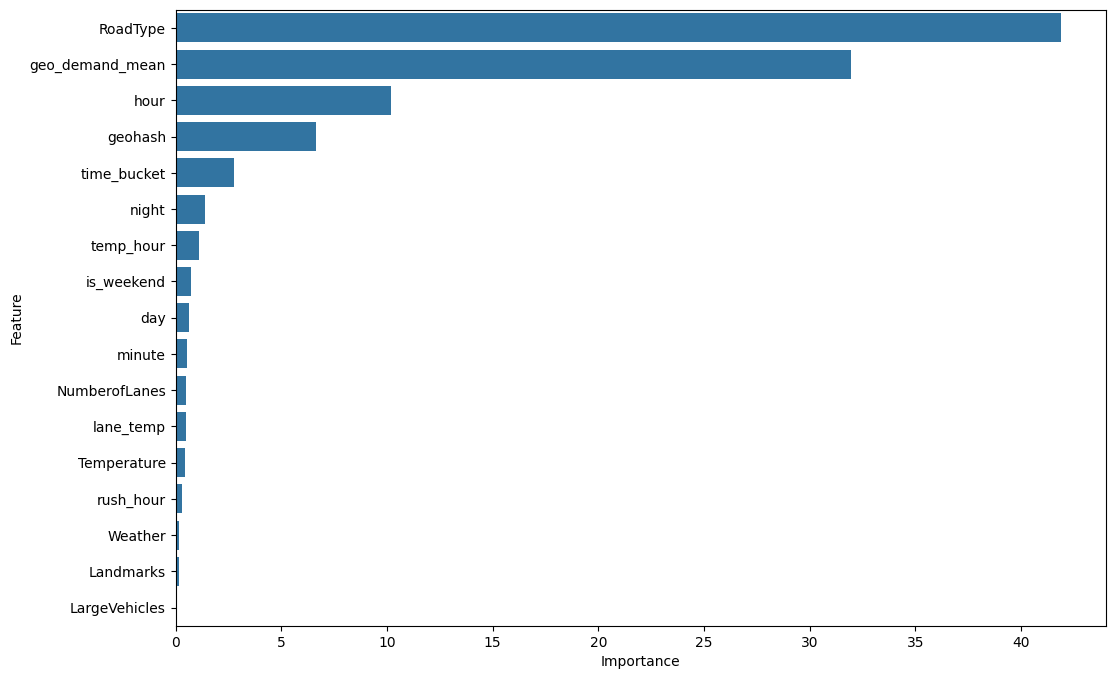

In [ ]:
# Importance Plot

plt.figure(figsize=(12,8))

sns.barplot(
    x=importance.head(20)["Importance"],
    y=importance.head(20)["Feature"]
)

plt.show()

In [ ]:
# KFold Setup

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Cross Validation

kfold_scores = cross_val_score(

    cat_model,

    X,

    y,

    scoring='r2',

    cv=kf
)

0:	learn: 0.0514190	total: 11.3ms	remaining: 22.5s
200:	learn: 0.9308822	total: 1.23s	remaining: 11s
400:	learn: 0.9413433	total: 2.39s	remaining: 9.54s
600:	learn: 0.9472465	total: 3.6s	remaining: 8.37s
800:	learn: 0.9512239	total: 4.77s	remaining: 7.15s
1000:	learn: 0.9542797	total: 5.95s	remaining: 5.94s
1200:	learn: 0.9567067	total: 7.16s	remaining: 4.76s
1400:	learn: 0.9587173	total: 8.43s	remaining: 3.61s
1600:	learn: 0.9604781	total: 9.66s	remaining: 2.41s
1800:	learn: 0.9619869	total: 11s	remaining: 1.21s
1999:	learn: 0.9633150	total: 12.3s	remaining: 0us
0:	learn: 0.0513708	total: 6.74ms	remaining: 13.5s
200:	learn: 0.9298930	total: 1.25s	remaining: 11.2s
400:	learn: 0.9406977	total: 2.53s	remaining: 10.1s
600:	learn: 0.9468613	total: 3.87s	remaining: 9.02s
800:	learn: 0.9511550	total: 5.12s	remaining: 7.66s
1000:	learn: 0.9543374	total: 6.39s	remaining: 6.38s
1200:	learn: 0.9567461	total: 7.65s	remaining: 5.09s
1400:	learn: 0.9587667	total: 8.86s	remaining: 3.79s
1600:	learn:

In [ ]:
# KFold Scores

kfold_scores

array([0.94800348, 0.94742827, 0.94938812, 0.94466258, 0.94923131])

In [ ]:
# Mean Score

kfold_scores.mean()

0.9477427522846325

In [ ]:
# Train Full Data

cat_model.fit(X, y)

lgb_model.fit(X, y)

xgb_model.fit(X, y)

0:	learn: 0.0515044	total: 7.59ms	remaining: 15.2s
200:	learn: 0.9308055	total: 1.34s	remaining: 12s
400:	learn: 0.9411493	total: 2.74s	remaining: 10.9s
600:	learn: 0.9467784	total: 4.21s	remaining: 9.81s
800:	learn: 0.9507744	total: 5.66s	remaining: 8.47s
1000:	learn: 0.9539916	total: 7.1s	remaining: 7.08s
1200:	learn: 0.9564129	total: 8.6s	remaining: 5.72s
1400:	learn: 0.9584350	total: 10s	remaining: 4.29s
1600:	learn: 0.9600645	total: 11.5s	remaining: 2.86s
1800:	learn: 0.9614675	total: 13s	remaining: 1.43s
1999:	learn: 0.9626890	total: 14.4s	remaining: 0us
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001978 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1335
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 17
[LightGBM] [Info] Start training from score 0.093942
[LightGBM] [Warning] No fur

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
# Test Predictions

cat_test_pred = cat_model.predict(X_test)

lgb_test_pred = lgb_model.predict(X_test)

xgb_test_pred = xgb_model.predict(X_test)

In [ ]:
# Final Ensemble

final_predictions = (

    0.45 * cat_test_pred +

    0.35 * lgb_test_pred +

    0.20 * xgb_test_pred
)

In [76]:
final_predictions.shape

(41778,)

In [ ]:
# Create Submission

submission = pd.DataFrame({

    "Index": test["Index"],

    "demand": final_predictions
})

In [ ]:
# View Submission

submission.head()

,Index,demand
0,0,0.060686
1,1,0.021871
2,2,0.031743
3,3,0.039329
4,4,0.050554


In [ ]:
# Save Submission

submission.to_csv(
    "submission.csv",
    index=False
)

In [ ]:
# Verify Submission

check = pd.read_csv("submission.csv")

check.head()

,Index,demand
0,0,0.060686
1,1,0.021871
2,2,0.031743
3,3,0.039329
4,4,0.050554


In [ ]:
# Submission Shape

check.shape

(41778, 2)

In [77]:
test.shape

(41778, 19)

In [78]:
test

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,is_weekend,rush_hour,night,time_bucket,lane_temp,temp_hour,geo_demand_mean
0,0,qp02z1,49,2:15,Unknown,1,Not Allowed,No,16.471232,Unknown,2,15,0,0,1,Night,16.471232,32.942464,0.040048
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy,2,15,0,0,1,Night,6.476213,12.952427,0.031742
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny,2,15,0,0,1,Night,66.954608,44.636405,0.029433
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,16.471232,Rainy,2,15,0,0,1,Night,32.942464,32.942464,0.039944
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy,2,15,0,0,1,Night,18.266162,36.532324,0.054593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,41773,qp0d4q,49,13:45,Street,1,Not Allowed,Yes,19.588991,Sunny,13,45,0,0,0,Afternoon,19.588991,254.656882,0.139208
41774,41774,qp0d4w,49,13:45,Residential,2,Not Allowed,Yes,10.735538,Rainy,13,45,0,0,0,Afternoon,21.471075,139.561989,0.113220
41775,41775,qp0dhq,49,13:45,Residential,2,Not Allowed,Yes,13.223750,Rainy,13,45,0,0,0,Afternoon,26.447500,171.908747,0.018066
41776,41776,qp0dhw,49,13:45,Residential,2,Not Allowed,Yes,12.510917,Rainy,13,45,0,0,0,Afternoon,25.021834,162.641918,0.075075


In [79]:
submission

,Index,demand
0,0,0.060686
1,1,0.021871
2,2,0.031743
3,3,0.039329
4,4,0.050554
...,...,...
41773,41773,0.295617
41774,41774,0.140646
41775,41775,0.017990
41776,41776,0.103004


In [80]:
comparison = pd.DataFrame({

    "Actual": y_valid.values,

    "Predicted": ensemble_pred
})

comparison.head(20)

,Actual,Predicted
0,0.132365,0.110497
1,0.088500,0.086365
2,0.032429,0.022243
3,0.027974,0.039543
4,0.047485,0.063240
5,0.043124,0.091471
6,0.401779,0.412688
7,0.060211,0.077065
8,0.109597,0.041834
9,0.004044,0.002701


In [81]:
comparison["Error"] = abs(
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison.head(20)

,Actual,Predicted,Error
0,0.132365,0.110497,0.021868
1,0.088500,0.086365,0.002135
2,0.032429,0.022243,0.010187
3,0.027974,0.039543,0.011569
4,0.047485,0.063240,0.015755
5,0.043124,0.091471,0.048347
6,0.401779,0.412688,0.010910
7,0.060211,0.077065,0.016854
8,0.109597,0.041834,0.067763
9,0.004044,0.002701,0.001344


In [82]:
ensemble_r2

0.9509918881209469